In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler


#### **Upload data**

In [36]:
df = pd.read_csv("../../Datasets/HR_attrition_rate.csv")
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [37]:
X = df[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company",
        "Work_accident",
        "promotion_last_5years"
    ]
]
print(X.shape)

(14999, 7)


## Mean Centering

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Covariance Matrix

In [39]:
cov_matrix = np.cov(X_scaled.T)
print(cov_matrix)

[[ 1.00006668  0.10502822 -0.14297912 -0.02004945 -0.1008728   0.05870115
   0.02560689]
 [ 0.10502822  1.00006668  0.34935588  0.33976445  0.1315995  -0.00710476
  -0.00868435]
 [-0.14297912  0.34935588  1.00006668  0.41723845  0.19679901 -0.00474086
  -0.00606436]
 [-0.02004945  0.33976445  0.41723845  1.00006668  0.12776343 -0.01014356
  -0.00354465]
 [-0.1008728   0.1315995   0.19679901  0.12776343  1.00006668  0.00212056
   0.06743742]
 [ 0.05870115 -0.00710476 -0.00474086 -0.01014356  0.00212056  1.00006668
   0.03924805]
 [ 0.02560689 -0.00868435 -0.00606436 -0.00354465  0.06743742  0.03924805
   1.00006668]]


## Eigenvalue & Eigenvector

In [40]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Mengurutkan
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

## Explained Variance

In [41]:
explained_variance = eigenvalues / np.sum(eigenvalues)

print("Eigenvalues")
print(eigenvalues)

print()

print("Explained Variance")
print(explained_variance)

Eigenvalues
[1.83017431 1.12659606 1.06036136 0.95598647 0.84548166 0.63363587
 0.54823098]

Explained Variance
[0.26143604 0.16093156 0.1514701  0.13656039 0.12077504 0.09051338
 0.07831349]


## Result

In [42]:
result = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue": eigenvalues,
    "Explained Variance": explained_variance,
    "Explained Variance (%)": explained_variance * 100
})

print(result)

  Principal Component  Eigenvalue  Explained Variance  Explained Variance (%)
0                 PC1    1.830174            0.261436               26.143604
1                 PC2    1.126596            0.160932               16.093156
2                 PC3    1.060361            0.151470               15.147010
3                 PC4    0.955986            0.136560               13.656039
4                 PC5    0.845482            0.120775               12.077504
5                 PC6    0.633636            0.090513                9.051338
6                 PC7    0.548231            0.078313                7.831349


In [43]:
result["Cumulative Variance (%)"] = result["Explained Variance (%)"].cumsum()

print(result)

  Principal Component  Eigenvalue  Explained Variance  Explained Variance (%)  \
0                 PC1    1.830174            0.261436               26.143604   
1                 PC2    1.126596            0.160932               16.093156   
2                 PC3    1.060361            0.151470               15.147010   
3                 PC4    0.955986            0.136560               13.656039   
4                 PC5    0.845482            0.120775               12.077504   
5                 PC6    0.633636            0.090513                9.051338   
6                 PC7    0.548231            0.078313                7.831349   

   Cumulative Variance (%)  
0                26.143604  
1                42.236761  
2                57.383770  
3                71.039809  
4                83.117314  
5                92.168651  
6               100.000000  


## Visualitation

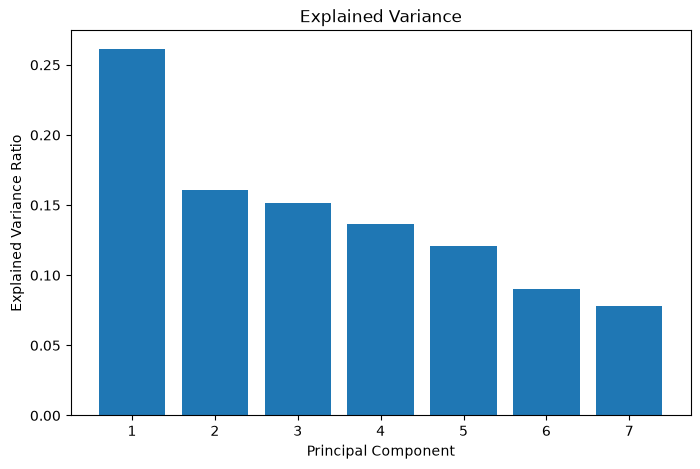

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained_variance)+1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance")

plt.show()

## Cummulative variance

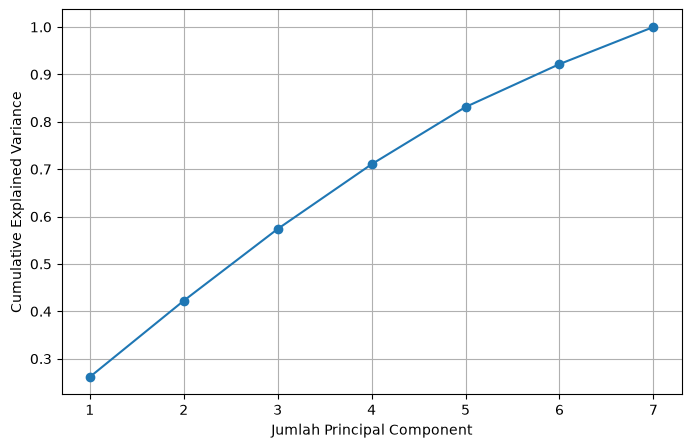

In [45]:
cumulative = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative)+1),
    cumulative,
    marker='o'
)

plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()